# Giải bài tập Phân tích Dữ liệu Hướng dẫn Vẽ biểu đồ
Dựa trên tập `Data_Chart_Excel.xlsx` và các câu hỏi trong `Cauhoi_Data_chart_Excel.xlsx`.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Thiết lập phong cách biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Đọc dữ liệu
df = pd.read_excel('Data_Chart_Excel.xlsx', skiprows=3)
display(df.head())

,Tháng,Quý,Chi nhánh,Nhóm hàng,Số đơn hàng,Doanh thu (trđ),Chi phí QC (trđ),Khách hàng mới
0,1,Quý 1,TP.HCM,Điện thoại,86,1074.8,64.5,24
1,1,Quý 1,TP.HCM,Laptop,44,893.0,56.4,12
2,1,Quý 1,TP.HCM,Phụ kiện,177,280.6,24.1,58
3,1,Quý 1,TP.HCM,Đồng hồ,65,380.3,31.1,22
4,1,Quý 1,Hà Nội,Điện thoại,73,824.7,59.3,18


### 1. Doanh thu toàn công ty thay đổi như thế nào qua 12 tháng trong năm?
- **Biểu đồ chọn**: Biểu đồ đường (Line Chart)
- **Lý do**: Thể hiện xu hướng thay đổi biến thiên của doanh thu theo thời gian (các tháng).

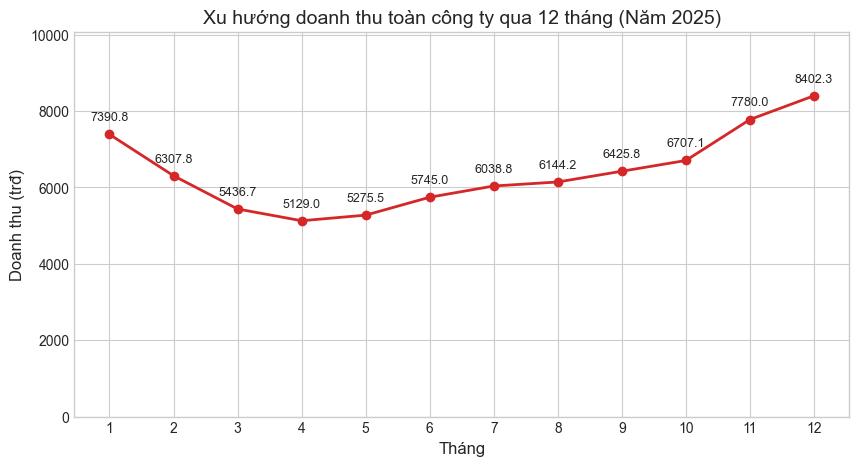

In [63]:
rev_by_month = df.groupby('Tháng')['Doanh thu (trđ)'].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(rev_by_month['Tháng'], rev_by_month['Doanh thu (trđ)'], marker='o', color='tab:red', linewidth=2)

# Thêm giá trị cụ thể lên từng điểm trên đường line (Data labels) để dễ đối chiếu
for i, txt in enumerate(rev_by_month['Doanh thu (trđ)'].round(1)):
    plt.annotate(f"{txt}", 
                 (rev_by_month['Tháng'][i], rev_by_month['Doanh thu (trđ)'][i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.title('Xu hướng doanh thu toàn công ty qua 12 tháng (Năm 2025)', fontsize=14)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Doanh thu (trđ)', fontsize=12)
plt.xticks(range(1, 13))
plt.ylim(0, rev_by_month['Doanh thu (trđ)'].max() * 1.2) # Tăng limit trục Y một chút để không bị lẹm số
plt.show()

### 2. Chi nhánh nào có tổng doanh thu cả năm cao nhất, thấp nhất?
- **Biểu đồ chọn**: Biểu đồ cột (Column Chart)
- **Lý do**: So sánh giá trị rời rạc giữa các nhóm khác nhau (chi nhánh).

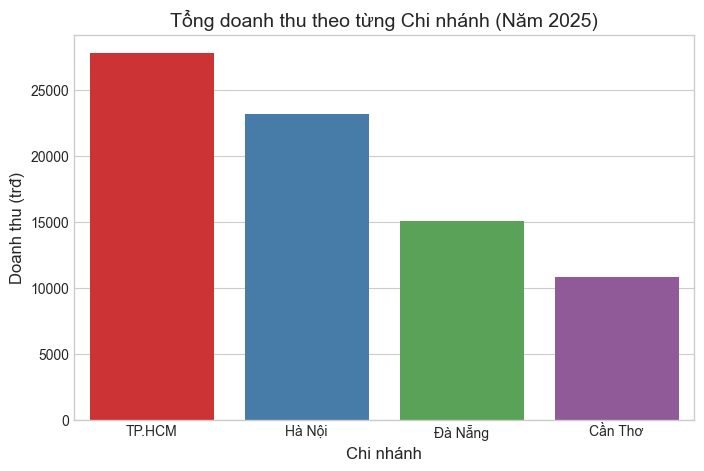

In [27]:
rev_by_branch = df.groupby('Chi nhánh')['Doanh thu (trđ)'].sum().reset_index().sort_values(by='Doanh thu (trđ)', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=rev_by_branch, x='Chi nhánh', y='Doanh thu (trđ)', palette='Set1')
plt.title('Tổng doanh thu theo từng Chi nhánh (Năm 2025)', fontsize=14)
plt.xlabel('Chi nhánh', fontsize=12)
plt.ylabel('Doanh thu (trđ)', fontsize=12)
plt.show()

### 3. Cơ cấu doanh thu cả năm theo nhóm hàng: mỗi nhóm chiếm bao nhiêu phần trăm?
- **Biểu đồ chọn**: Biểu đồ tròn (Pie Chart) hoặc Donut Chart
- **Lý do**: Xem tỷ trọng đóng góp của mỗi phần tử (nhóm hàng) trong tổng thể (100%).

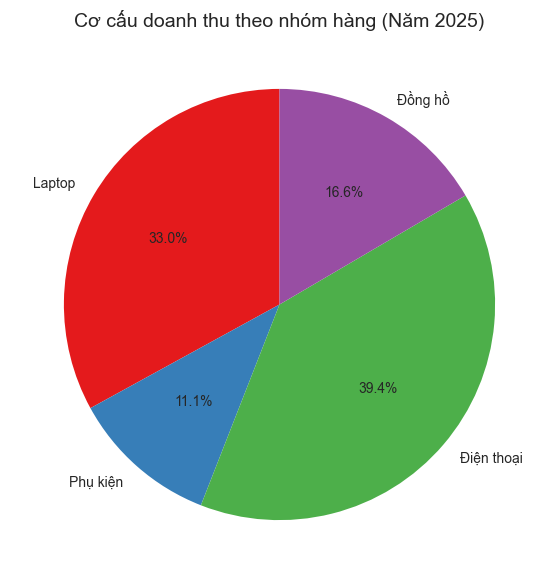

In [28]:
rev_by_product = df.groupby('Nhóm hàng')['Doanh thu (trđ)'].sum().reset_index()

plt.figure(figsize=(7, 7))
plt.pie(rev_by_product['Doanh thu (trđ)'], labels=rev_by_product['Nhóm hàng'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set1'))
plt.title('Cơ cấu doanh thu theo nhóm hàng (Năm 2025)', fontsize=14)
plt.show()

### 4. Trong từng quý, mỗi chi nhánh đóng góp doanh thu ra sao và tổng mỗi quý là bao nhiêu?
- **Biểu đồ chọn**: Biểu đồ cột chồng (Stacked Column Chart)
- **Lý do**: Thể hiện được tổng doanh thu mỗi quý, đồng thời chia tách được thành phần đóng góp của mỗi chi nhánh vào cái tổng đó.

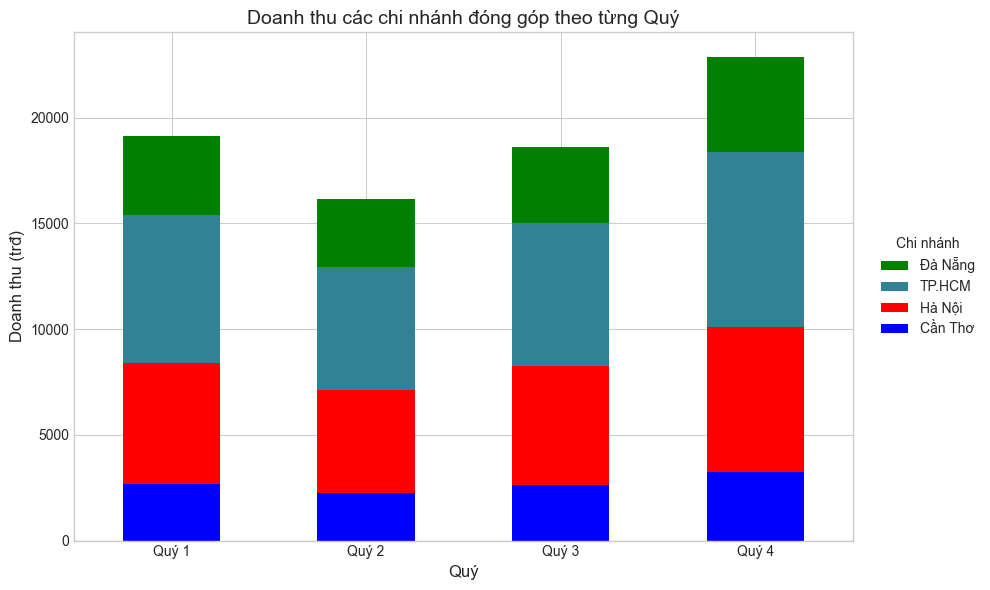

In [38]:
from matplotlib.colors import ListedColormap

rev_branch_quarter = df.pivot_table(index='Quý', columns='Chi nhánh', values='Doanh thu (trđ)', aggfunc='sum')

# Tạo dải màu tùy chỉnh tương tự như hình (Xanh dương, Đỏ, Xanh mòng két, Xanh lá)
custom_cmap = ListedColormap(['blue', 'red', '#328296', 'green'])

ax = rev_branch_quarter.plot(kind='bar', stacked=True, figsize=(10, 6), colormap=custom_cmap)
plt.title('Doanh thu các chi nhánh đóng góp theo từng Quý', fontsize=14)
plt.xlabel('Quý', fontsize=12)
plt.ylabel('Doanh thu (trđ)', fontsize=12)
plt.xticks(rotation=0)

# Đảo ngược thứ tự chú thích để đồng nhất với chiều xếp chồng của biểu đồ cột
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='Chi nhánh', bbox_to_anchor=(1.02, 0.5), loc='center left')

plt.tight_layout() # Đảm bảo biểu đồ không bị cắt lẹm khi đưa chú thích ra ngoài
plt.show()

### 5. Chi phí quảng cáo có thực sự đi kèm doanh thu cao hơn không? Quan hệ giữa hai chỉ số này?
- **Biểu đồ chọn**: Biểu đồ phân tán (Scatter Plot)
- **Lý do**: Xem xét sự tương quan giữa hai biến số lượng (Chi phí QC và Doanh thu).

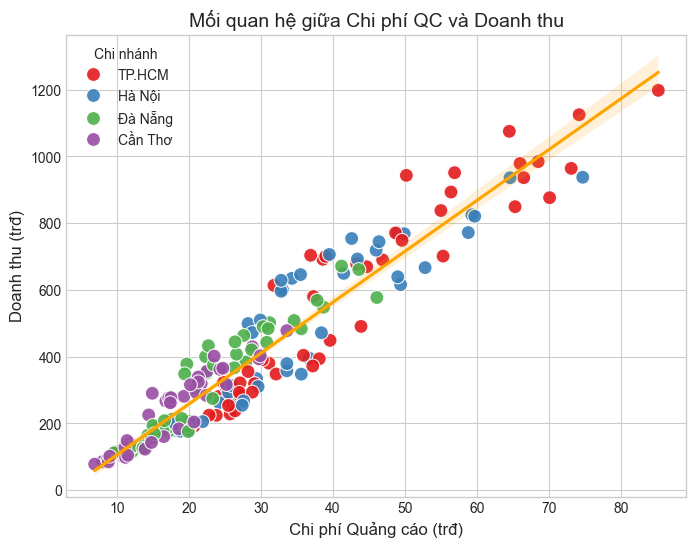

In [50]:
plt.figure(figsize=(8, 6))

# Vẽ biểu đồ phân tán
sns.scatterplot(data=df, x='Chi phí QC (trđ)', y='Doanh thu (trđ)', hue='Chi nhánh', palette='Set1', s=100, alpha=0.9)

# Thêm đường xu hướng (Trendline) tổng thể
sns.regplot(data=df, x='Chi phí QC (trđ)', y='Doanh thu (trđ)', scatter=False, color='orange', line_kws={"linestyle": "-"})

plt.title('Mối quan hệ giữa Chi phí QC và Doanh thu', fontsize=14)
plt.xlabel('Chi phí Quảng cáo (trđ)', fontsize=12)
plt.ylabel('Doanh thu (trđ)', fontsize=12)
plt.show()

### 6. Giá trị doanh thu của mỗi dòng phân bố thế nào – phần lớn rơi vào khoảng nào?
- **Biểu đồ chọn**: Biểu đồ phân bố (Histogram)
- **Lý do**: Đếm số lượng quan sát (tần suất) rơi vào các khoảng giá trị của biến liên tục.

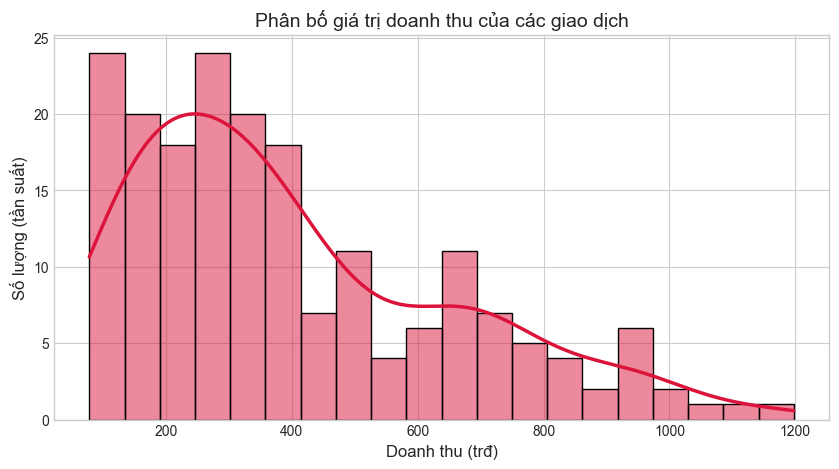

In [52]:
plt.figure(figsize=(10, 5))
# Sử dụng line_kws để làm cho đường KDE (đường xu hướng phân bố) đổi màu và nổi bật hơn so với cột
sns.histplot(df['Doanh thu (trđ)'], bins=20, kde=True, color='crimson', line_kws={'color': 'navy', 'linewidth': 2.5})
plt.title('Phân bố giá trị doanh thu của các giao dịch', fontsize=14)
plt.xlabel('Doanh thu (trđ)', fontsize=12)
plt.ylabel('Số lượng (tần suất)', fontsize=12)
plt.show()

### 7. So sánh đồng thời Doanh thu và Số đơn hàng theo từng tháng (hai chỉ số khác thang đo).
- **Biểu đồ chọn**: Biểu đồ kết hợp (Combo Chart - cột và đường có 2 trục Y)
- **Lý do**: Có hai biến với đơn vị và thang đo khác nhau (doanh thu trđ, và số đơn chiếc).

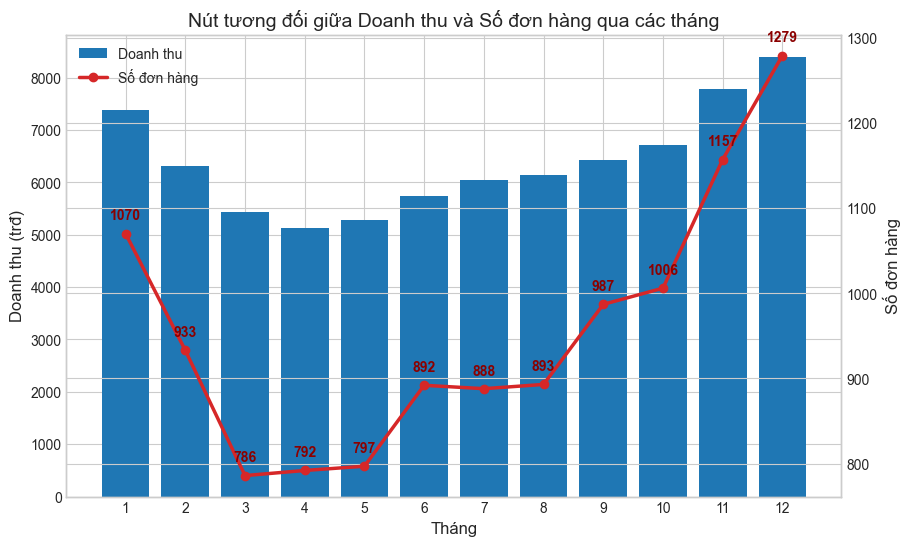

In [55]:
rev_orders_month = df.groupby('Tháng')[['Doanh thu (trđ)', 'Số đơn hàng']].sum().reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Doanh thu (Cột - Trục trái)
ax1.bar(rev_orders_month['Tháng'], rev_orders_month['Doanh thu (trđ)'], color='tab:blue', label='Doanh thu')
ax1.set_xlabel('Tháng', fontsize=12)
ax1.set_ylabel('Doanh thu (trđ)', fontsize=12)
ax1.set_xticks(range(1, 13))

# Thêm giá trị cho Doanh thu trên đỉnh mỗi cột (Tùy chọn)

# Số đơn hàng (Đường - Trục phải)
ax2 = ax1.twinx()
ax2.plot(rev_orders_month['Tháng'], rev_orders_month['Số đơn hàng'], color='tab:red', marker='o', linewidth=2.5, label='Số đơn hàng')
ax2.set_ylabel('Số đơn hàng', fontsize=12)

# Hiển thị số liệu (Data labels) cho Số đơn hàng
for i, txt in enumerate(rev_orders_month['Số đơn hàng']):
    ax2.annotate(txt, (rev_orders_month['Tháng'][i], rev_orders_month['Số đơn hàng'][i]), 
                 textcoords="offset points", xytext=(0,10), ha='center',
                 fontsize=10, fontweight='bold', color='darkred')

# Hiển thị chú thích
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Nút tương đối giữa Doanh thu và Số đơn hàng qua các tháng', fontsize=14)
plt.show()

### 8. Xếp hạng 16 tổ hợp Chi nhánh × Nhóm hàng theo số khách hàng mới thu hút được.
- **Biểu đồ chọn**: Biểu đồ thanh ngang (Bar Chart)
- **Lý do**: Xếp hạng với nhãn trục danh mục rất dài (Tổ hợp Chi nhánh x Nhóm hàng), thanh ngang giúp đồ thị dễ đọc (sắp xếp giảm dần).

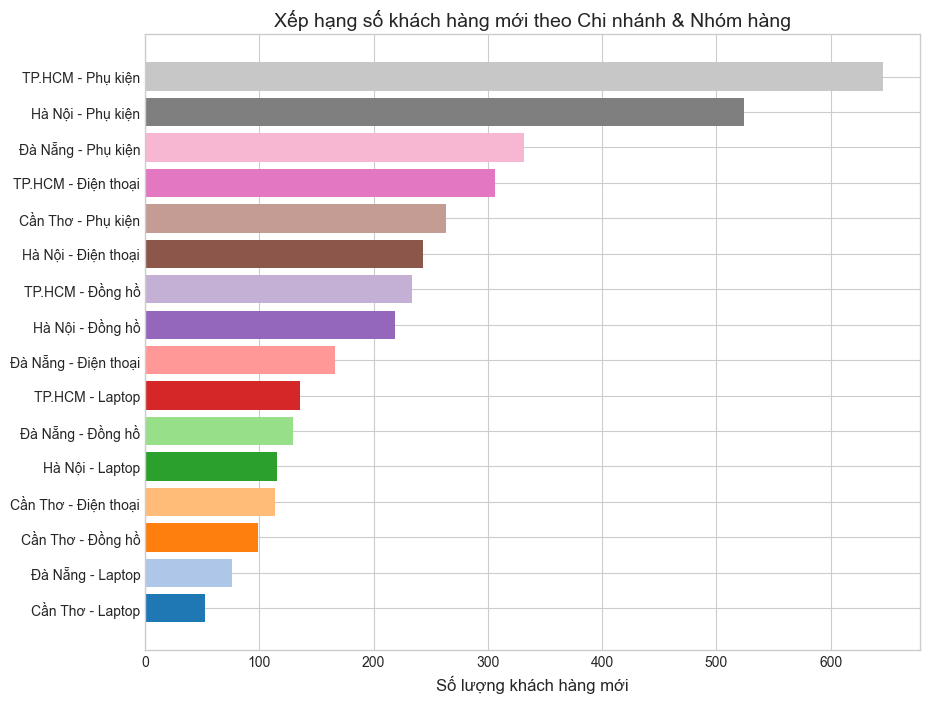

In [56]:
df['Chi nhánh_Nhóm'] = df['Chi nhánh'] + ' - ' + df['Nhóm hàng']
cust_by_combo = df.groupby('Chi nhánh_Nhóm')['Khách hàng mới'].sum().reset_index()
cust_by_combo = cust_by_combo.sort_values(by='Khách hàng mới', ascending=True) # Ascending để khi vẽ hbar hiển thị lớn nhất ở trên

plt.figure(figsize=(10, 8))
# Sử dụng sns.color_palette để tự động tạo ra một danh sách các màu khác nhau cho mỗi thanh
colors = sns.color_palette('tab20', len(cust_by_combo))
plt.barh(cust_by_combo['Chi nhánh_Nhóm'], cust_by_combo['Khách hàng mới'], color=colors)

plt.title('Xếp hạng số khách hàng mới theo Chi nhánh & Nhóm hàng', fontsize=14)
plt.xlabel('Số lượng khách hàng mới', fontsize=12)
plt.show()

### 9. Số đơn hàng cộng dồn (luỹ kế) tăng lên theo thời gian như thế nào trong năm?
- **Biểu đồ chọn**: Biểu đồ vùng (Area Chart)
- **Lý do**: Thể hiện được trị số cộng dồn lũy kế qua từng mốc thời gian, tạo cảm giác về khối lượng tích lũy.

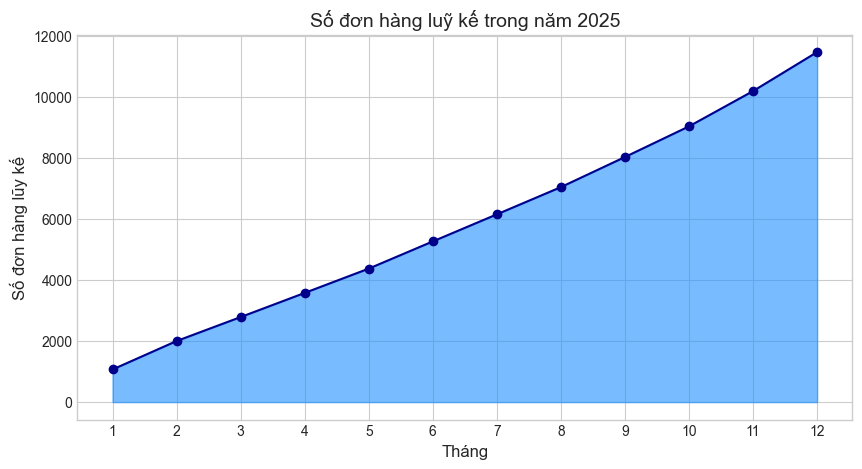

In [57]:
orders_cumulative = df.groupby('Tháng')['Số đơn hàng'].sum().reset_index()
orders_cumulative['Cộng dồn'] = orders_cumulative['Số đơn hàng'].cumsum()

plt.figure(figsize=(10, 5))
plt.fill_between(orders_cumulative['Tháng'], orders_cumulative['Cộng dồn'], color='dodgerblue', alpha=0.6)
plt.plot(orders_cumulative['Tháng'], orders_cumulative['Cộng dồn'], color='darkblue', marker='o')

plt.title('Số đơn hàng luỹ kế trong năm 2025', fontsize=14)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Số đơn hàng lũy kế', fontsize=12)
plt.xticks(range(1, 13))
plt.show()